# Baslines: Vergleich der ANOVA-GP-Modelle mit klassischen und vortrainierten Baselines

Dieses Notebook vergleicht die bereits exportierten Vorhersagen der additiven und epistatischen ANOVA-GPs mit Baselines, die auf exakt denselben 35 NylC-Varianten ausgewertet werden. Für Modelle mit Hyperparametern erfolgt die Auswahl ausschließlich im jeweiligen äußeren Trainingsfold (nested LOOCV).

Enthalten sind: Trainingsmittelwert und Mutationsanzahl als einfache Referenzen sowie Ridge, kNN, Bayesian Ridge, Random Forest, optional TabICL V2 und der Hardened-GP auf demselben Physical-Feature-Satz (zwei Deskriptoren je Zielposition). ESM-2 wird ausschließlich über echte Likelihood-Ratio-Scores integriert: direkt ohne Assaytraining, als zusätzliches Ridge-Merkmal und als Prior-Mittelwert des epistatischen ANOVA-GP. Eingefrorene ESM-2-Embeddings werden nicht verwendet.

> **TabICL-Hinweis:** TabICL V2 wurde laut offizieller Dokumentation auf Tabellen mit 300 bis 48.000 Trainingszeilen vortrainiert und bislang nicht für weniger als 300 Zeilen untersucht. Die Ergebnisse bei 35 Varianten sind daher explorativ.

Quellen: [TabICL V2](https://arxiv.org/abs/2602.11139), [offizielle Implementierung](https://github.com/soda-inria/tabicl).

## 1. Konfiguration

Mit `HARDWARE_PROFILE = 'laptop'` läuft die ressourcenschonende CPU-Konfiguration; `HARDWARE_PROFILE = 'pc'` aktiviert die CUDA-Konfiguration für eine NVIDIA-GPU. Modell, Batchgröße und TabICL werden daraus automatisch abgeleitet. Beim ersten ESM-2-Lauf werden die Likelihood-Scores berechnet und anschließend als CSV sowie im Modellcache gespeichert.

### Einmalige Installation im aktiven Notebook-Kernel

Die Pakete müssen in genau dem Python-Kernel installiert sein, mit dem dieses Notebook läuft. Die PyTorch-Variante (CPU oder CUDA) wird bewusst **nicht im Notebook installiert**, weil ein Wechsel normalerweise einen Kernel-Neustart erfordert. CPU-Beispiel:

```python
python -m pip install torch --index-url https://download.pytorch.org/whl/cpu
python -m pip install transformers
```

Danach den Kernel vollständig neu starten. Für eine NVIDIA-GPU bitte stattdessen auf der offiziellen PyTorch-Seite die zum Treiber passende CUDA-Installation auswählen. Zum schnellen Funktionstest kann `ESM2_ZERO_SHOT_MODEL` vorübergehend auf `facebook/esm2_t6_8M_UR50D` gesetzt werden; die Hauptauswertung soll mit dem voreingestellten 650M-Modell erfolgen.

In [1]:
import torch
import transformers
print('PyTorch:', torch.__version__)
print('CUDA verfügbar:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

c:\Users\Arthur Hehner\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\.venv-anova-gp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cu130
CUDA verfügbar: True
GPU: NVIDIA GeForce RTX 3070


In [2]:
from itertools import product
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# Einzige Umschaltvariable: 'laptop' (CPU) oder 'pc' (NVIDIA/CUDA).
HARDWARE_PROFILE = 'pc'

HARDWARE_PROFILES = {
    'laptop': {
        'device': 'cpu',
        'esm2_model': 'facebook/esm2_t6_8M_UR50D',
        'esm2_batch_size': 2,
        'run_tabicl': False,
    },
    'pc': {
        'device': 'cuda',
        'esm2_model': 'facebook/esm2_t33_650M_UR50D',
        # Konservativ für 8 GB VRAM (z. B. RTX 3070).
        'esm2_batch_size': 2,
        'run_tabicl': True,
    },
}
if HARDWARE_PROFILE not in HARDWARE_PROFILES:
    raise ValueError(f'Unbekanntes HARDWARE_PROFILE: {HARDWARE_PROFILE!r}')
PROFILE = HARDWARE_PROFILES[HARDWARE_PROFILE]

import torch
if PROFILE['device'] == 'cuda' and not torch.cuda.is_available():
    raise RuntimeError(
        "PC-Profil gewählt, aber CUDA ist in diesem Kernel nicht verfügbar. "
        "Installiere eine CUDA-fähige PyTorch-Version und starte den Kernel neu."
    )

RUN_TABICL = PROFILE['run_tabicl']
RUN_ESM2_ZERO_SHOT = True
ESM2_DEVICE = PROFILE['device']
ESM2_ZERO_SHOT_MODEL = PROFILE['esm2_model']
ESM2_BATCH_SIZE = PROFILE['esm2_batch_size']
TABICL_N_ESTIMATORS = 8
print(f'Hardware-Profil: {HARDWARE_PROFILE} | Device: {ESM2_DEVICE} | ESM-2: {ESM2_ZERO_SHOT_MODEL}')

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'matrices' / 'NylC_Puetz_raw_data.CSV').exists():
            return candidate
    if start.name == 'Notebooks':
        return start.parent
    raise FileNotFoundError('Projektwurzel mit matrices/NylC_Puetz_raw_data.CSV nicht gefunden.')

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'matrices' / 'NylC_Puetz_raw_data.CSV'
GP_RESULT_DIR = PROJECT_ROOT / 'results' / 'anova_gp_reviewed'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'baseline_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Projekt:', PROJECT_ROOT)
print('Ausgabe:', OUTPUT_DIR)

Hardware-Profil: pc | Device: cuda | ESM-2: facebook/esm2_t33_650M_UR50D
Projekt: c:\Users\Arthur Hehner\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features
Ausgabe: c:\Users\Arthur Hehner\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\results\baseline_comparison


## 2. Aktivitätsdaten und vier Zielpositionen

Die Zielgröße ist der Mittelwert der verfügbaren PA6-Replikate. Varianten mit Mutationen außerhalb der Positionen 99, 134, 304 und 330 werden wie im GP-Notebook ausgeschlossen.

In [3]:
WT_POCKET = {99: 'D', 134: 'F', 304: 'D', 330: 'R'}
POSITIONS = tuple(WT_POCKET)
CANONICAL_AA = tuple('ACDEFGHIKLMNPQRSTVWY')
MUTATION_PATTERN = re.compile(r'([A-Z])(\d+)([A-Z])')

def parse_mutations(value):
    pocket = dict(WT_POCKET)
    mutations = []
    if pd.isna(value) or str(value).strip().lower() in {'', 'wt', 'wildtype', 'wild type', 'nan'}:
        return pocket, mutations
    for wt_aa, pos_text, mut_aa in MUTATION_PATTERN.findall(str(value).upper()):
        pos = int(pos_text)
        mutations.append((wt_aa, pos, mut_aa))
        if pos in pocket:
            if pocket[pos] != wt_aa:
                warnings.warn(f'Unerwartete WT-Aminosäure in {wt_aa}{pos}{mut_aa}.')
            pocket[pos] = mut_aa
    return pocket, mutations

df_raw = pd.read_csv(DATA_PATH, sep=';', decimal=',')
replicate_cols = [c for c in df_raw if c.startswith('activity_pa6_')]
df_raw[replicate_cols] = df_raw[replicate_cols].apply(pd.to_numeric, errors='coerce')
df_raw['activity_pa6'] = df_raw[replicate_cols].mean(axis=1, skipna=True)
df_raw['activity_n'] = df_raw[replicate_cols].count(axis=1)
df_raw['activity_sd'] = df_raw[replicate_cols].std(axis=1, skipna=True, ddof=1)
df_raw['activity_sem'] = df_raw['activity_sd'] / np.sqrt(df_raw['activity_n'])
fallback_sem = df_raw.loc[df_raw['activity_sem'].gt(0), 'activity_sem'].median()
df_raw['activity_sem_for_gp'] = df_raw['activity_sem'].fillna(fallback_sem)
parsed = df_raw['mutations'].apply(parse_mutations)
df_raw['pocket'] = parsed.apply(lambda x: x[0])
df_raw['parsed_mutations'] = parsed.apply(lambda x: x[1])
df_raw['mutation_positions'] = df_raw['parsed_mutations'].apply(lambda xs: {p for _, p, _ in xs})
df_raw['mutation_order'] = df_raw['parsed_mutations'].apply(len)
df_raw['mutation_signature'] = df_raw['mutation_positions'].apply(
    lambda ps: 'WT' if not ps else '+'.join(map(str, sorted(ps)))
)
df = df_raw[df_raw['mutation_positions'].apply(lambda ps: ps.issubset(POSITIONS))].copy().reset_index(drop=True)
assert df['variant_id'].is_unique
assert df['activity_pa6'].notna().all()
print(f'{len(df)} Varianten, Aktivitätsbereich {df.activity_pa6.min():.2f}–{df.activity_pa6.max():.2f}')
display(df[['variant_id', 'mutations', 'mutation_signature', 'mutation_order', 'activity_pa6']])

35 Varianten, Aktivitätsbereich 77.67–520.00


,variant_id,mutations,mutation_signature,mutation_order,activity_pa6
0,WT,NaN,WT,0,77.666667
1,D99G,D99G,99,1,144.000000
2,D99V,D99V,99,1,147.666667
3,D99R,D99R,99,1,194.000000
4,F134W,F134W,134,1,217.000000
5,D304M,D304M,304,1,233.500000
6,D304E,D304E,304,1,171.250000
7,D304Q,D304Q,304,1,157.000000
8,D304V,D304V,304,1,131.500000
9,D304W,D304W,304,1,130.000000


## 3. Merkmalsdarstellungen

Alle trainierbaren Modellarchitekturen verwenden dieselben acht Physical-Merkmale: zwei über alle 20 kanonischen Aminosäuren standardisierte Deskriptoren je Zielposition. PD1 beschreibt vor allem das Volumen, PD2 die Hydrophilie. Der ESM-2-Zero-Shot-Score ist die Summe der Mutanten-gegen-WT-Log-Likelihood-Verhältnisse an allen gleichzeitig maskierten Mutationspositionen; er ist ein skalares Merkmal und kein Embedding.

In [4]:
def physical_features(frame):
    try:
        from peptides import Peptide
    except ImportError as exc:
        raise ImportError('Für Physical-Deskriptoren bitte `pip install peptides` ausführen.') from exc
    raw = np.vstack([np.asarray(Peptide(aa).physical_descriptors(), dtype=float) for aa in CANONICAL_AA])
    scaled = (raw - raw.mean(axis=0)) / raw.std(axis=0, ddof=0)
    aa_table = {aa: scaled[i] for i, aa in enumerate(CANONICAL_AA)}
    columns = [f'pos{pos}_PD{i}' for pos in POSITIONS for i in range(1, raw.shape[1] + 1)]
    rows = [np.concatenate([aa_table[pocket[pos]] for pos in POSITIONS]) for pocket in frame['pocket']]
    return pd.DataFrame(rows, columns=columns, index=frame.index)

X_count = df[['mutation_order']].astype(float)
X_physical = physical_features(df)
FEATURES = {
    'mutation_count': X_count,
    'physical': X_physical,
}
def compute_esm2_zero_shot_scores(frame):
    import sys
    scripts_dir = PROJECT_ROOT / 'scripts'
    if str(scripts_dir) not in sys.path:
        sys.path.insert(0, str(scripts_dir))
    from protein_llm_embeddings import read_fasta_sequence
    from esm2_zero_shot import ESM2ZeroShotScorer
    scorer = ESM2ZeroShotScorer(
        wt_sequence=read_fasta_sequence(PROJECT_ROOT / 'inputs' / 'variant_fastas' / 'WT.fasta'),
        wt_pocket=WT_POCKET, model_name=ESM2_ZERO_SHOT_MODEL,
        cache_dir=PROJECT_ROOT / 'results' / 'esm2_zero_shot_cache',
        batch_size=ESM2_BATCH_SIZE, device=ESM2_DEVICE, local_files_only=False
    )
    return scorer.score_pockets(frame['pocket'].tolist())

ZERO_SHOT_PATH = OUTPUT_DIR / 'esm2_zero_shot_scores.csv'
if RUN_ESM2_ZERO_SHOT:
    df['esm2_zero_shot'] = compute_esm2_zero_shot_scores(df)
    df[['variant_id', 'esm2_zero_shot']].to_csv(ZERO_SHOT_PATH, index=False)
elif ZERO_SHOT_PATH.exists():
    cached_scores = pd.read_csv(ZERO_SHOT_PATH)
    df = df.merge(cached_scores, on='variant_id', how='left', validate='one_to_one')
else:
    df['esm2_zero_shot'] = np.nan
    print('ESM-2-Zero-Shot übersprungen. RUN_ESM2_ZERO_SHOT=True setzen.')

pd.DataFrame({'representation': FEATURES.keys(), 'n_features': [x.shape[1] for x in FEATURES.values()]})

c:\Users\Arthur Hehner\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\.venv-anova-gp\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Arthur Hehner\.cache\huggingface\hub\models--facebook--esm2_t33_650M_UR50D. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 539/539 

,representation,n_features
0,mutation_count,1
1,physical,8


## 4. Gemeinsame Metriken und verschachtelte LOOCV

MAE ist die primäre Auswahlmetrik. RMSE, R², Pearson und Spearman werden ergänzend berichtet. Alle trainierbaren Baseline-Architekturen erhalten dieselben acht Physical-Merkmale wie der Hardened-GP. Bei Ridge und kNN wird der Hyperparameter ausschließlich durch eine innere LOOCV des äußeren Trainingsfolds gewählt.

In [5]:
def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'r2': r2_score(y_true, y_pred),
        'pearson': pearsonr(y_true, y_pred).statistic,
        'spearman': spearmanr(y_true, y_pred).statistic,
    }

def inner_loocv_mae(estimator, X, y):
    predictions = np.empty(len(y), dtype=float)
    for valid_idx in range(len(y)):
        train_idx = np.delete(np.arange(len(y)), valid_idx)
        fitted = clone(estimator).fit(X.iloc[train_idx], y[train_idx])
        predictions[valid_idx] = fitted.predict(X.iloc[[valid_idx]])[0]
    return mean_absolute_error(y, predictions)

def nested_loocv_candidates(frame, X, model_name, candidates):
    y = frame['activity_pa6'].to_numpy(float)
    rows = []
    for test_idx in range(len(frame)):
        train_idx = np.delete(np.arange(len(frame)), test_idx)
        scores = [inner_loocv_mae(est, X.iloc[train_idx], y[train_idx]) for _, est in candidates]
        best_idx = int(np.argmin(scores))
        setting, estimator = candidates[best_idx]
        fitted = clone(estimator).fit(X.iloc[train_idx], y[train_idx])
        prediction = float(fitted.predict(X.iloc[[test_idx]])[0])
        rows.append({
            'model': model_name,
            'variant_id': frame.loc[test_idx, 'variant_id'],
            'mutation_signature': frame.loc[test_idx, 'mutation_signature'],
            'mutation_order': int(frame.loc[test_idx, 'mutation_order']),
            'observed': y[test_idx],
            'predicted': prediction,
            'abs_error': abs(y[test_idx] - prediction),
            'selected_setting': setting,
            'inner_mae': scores[best_idx],
        })
    return pd.DataFrame(rows)

def fixed_outer_loocv(frame, X, model_name, estimator):
    y = frame['activity_pa6'].to_numpy(float)
    rows = []
    for test_idx in range(len(frame)):
        train_idx = np.delete(np.arange(len(frame)), test_idx)
        fitted = clone(estimator).fit(X.iloc[train_idx], y[train_idx])
        prediction = float(fitted.predict(X.iloc[[test_idx]])[0])
        rows.append({'model': model_name, 'variant_id': frame.loc[test_idx, 'variant_id'],
                     'mutation_signature': frame.loc[test_idx, 'mutation_signature'],
                     'mutation_order': int(frame.loc[test_idx, 'mutation_order']),
                     'observed': y[test_idx], 'predicted': prediction,
                     'abs_error': abs(y[test_idx] - prediction), 'selected_setting': 'pre-specified'})
    return pd.DataFrame(rows)

def summarize_predictions(predictions):
    rows = []
    for name, group in predictions.groupby('model'):
        if name == 'esm2_zero_shot_direct':
            rows.append({
                'model': name, 'mae': np.nan, 'rmse': np.nan, 'r2': np.nan,
                'pearson': pearsonr(group.observed, group.predicted).statistic,
                'spearman': spearmanr(group.observed, group.predicted).statistic,
            })
        else:
            rows.append({'model': name, **regression_metrics(group.observed, group.predicted)})
    return pd.DataFrame(rows).sort_values('mae', na_position='last').reset_index(drop=True)

## 5. Klassische Baselines

In [6]:
ALPHAS = (0.01, 0.1, 1.0, 10.0, 100.0)
ridge_candidates = lambda: [(f'alpha={a}', make_pipeline(StandardScaler(), Ridge(alpha=a))) for a in ALPHAS]

prediction_frames = []
y = df['activity_pa6'].to_numpy(float)
mean_rows = []
for test_idx in range(len(df)):
    train_idx = np.delete(np.arange(len(df)), test_idx)
    pred = float(y[train_idx].mean())
    mean_rows.append({'model': 'train_mean', 'variant_id': df.loc[test_idx, 'variant_id'],
                      'mutation_signature': df.loc[test_idx, 'mutation_signature'],
                      'mutation_order': int(df.loc[test_idx, 'mutation_order']),
                      'observed': y[test_idx], 'predicted': pred, 'abs_error': abs(y[test_idx] - pred)})
prediction_frames.append(pd.DataFrame(mean_rows))

for model_name, representation in [
    ('ridge_mutation_count', 'mutation_count'),
    ('ridge_physical', 'physical'),
]:
    print(model_name)
    prediction_frames.append(nested_loocv_candidates(df, FEATURES[representation], model_name, ridge_candidates()))

prediction_frames.append(nested_loocv_candidates(
    df, X_physical, 'knn_physical',
    [(f'k={k}', make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k, weights='distance')))
     for k in (1, 3, 5, 7)]
))
prediction_frames.append(fixed_outer_loocv(
    df, X_physical, 'bayesian_ridge_physical', make_pipeline(StandardScaler(), BayesianRidge())
))

if df['esm2_zero_shot'].notna().all():
    direct = df[['variant_id', 'mutation_signature', 'mutation_order', 'activity_pa6', 'esm2_zero_shot']].copy()
    direct = direct.rename(columns={'activity_pa6': 'observed', 'esm2_zero_shot': 'predicted'})
    direct['model'] = 'esm2_zero_shot_direct'
    direct['abs_error'] = np.nan  # Score ist nicht in Aktivitätseinheiten kalibriert.
    prediction_frames.append(direct)

    X_ridge_zero_shot = X_physical.copy()
    X_ridge_zero_shot['esm2_zero_shot'] = df['esm2_zero_shot'].to_numpy(float)
    prediction_frames.append(nested_loocv_candidates(
        df, X_ridge_zero_shot, 'ridge_physical_plus_esm2_zero_shot', ridge_candidates()
    ))

ridge_mutation_count
ridge_physical


## 6. Random Forest

Die Konfiguration wird vorab festgelegt und nicht anhand der Gesamtdaten ausgewählt. Das vermeidet bei nur 35 Beobachtungen einen unverhältnismäßigen inneren Suchraum und entspricht der bereits verwendeten Random-Forest-Baseline.

In [7]:
rf = RandomForestRegressor(
    n_estimators=500, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
)
prediction_frames.append(fixed_outer_loocv(df, X_physical, 'random_forest_physical_fixed', rf))

## 7. TabICL V2 (optional und explorativ)

TabICL wird ohne Fine-Tuning verwendet. Jede äußere LOOCV-Vorhersage erhält nur die übrigen Varianten als In-Context-Trainingsdaten und verwendet denselben Physical-Feature-Satz wie der Hardened-GP.

Installation: `%pip install tabicl`

Danach `RUN_TABICL = True` in der Konfiguration setzen und dieses Notebook erneut ausführen.

In [9]:
%pip install tabicl

def tabicl_loocv(frame, X, model_name):
    from tabicl import TabICLRegressor
    y = frame['activity_pa6'].to_numpy(float)
    rows = []
    for test_idx in range(len(frame)):
        train_idx = np.delete(np.arange(len(frame)), test_idx)
        model = TabICLRegressor(
            n_estimators=TABICL_N_ESTIMATORS, random_state=RANDOM_STATE,
            checkpoint_version='tabicl-regressor-v2-20260212.ckpt',
            allow_auto_download=True, verbose=False
        )
        model.fit(X.iloc[train_idx], y[train_idx])
        pred = float(np.asarray(model.predict(X.iloc[[test_idx]])).reshape(-1)[0])
        rows.append({'model': model_name, 'variant_id': frame.loc[test_idx, 'variant_id'],
                     'mutation_signature': frame.loc[test_idx, 'mutation_signature'],
                     'mutation_order': int(frame.loc[test_idx, 'mutation_order']),
                     'observed': y[test_idx], 'predicted': pred,
                     'abs_error': abs(y[test_idx] - pred),
                     'selected_setting': f'n_estimators={TABICL_N_ESTIMATORS}'})
        print(f'{model_name}: {test_idx + 1:02d}/{len(frame)}')
    return pd.DataFrame(rows)

if RUN_TABICL:
    prediction_frames.append(tabicl_loocv(df, X_physical, 'tabicl_v2_physical'))
else:
    print('TabICL übersprungen. Für den Lauf RUN_TABICL = True setzen.')


   ---------------------------------------- 0/2 [einops]
   ---------------------------------------- 0/2 [einops]
   -------------------- ------------------- 1/2 [tabicl]
   -------------------- ------------------- 1/2 [tabicl]
   -------------------- ------------------- 1/2 [tabicl]
   -------------------- ------------------- 1/2 [tabicl]
   -------------------- ------------------- 1/2 [tabicl]
   -------------------- ------------------- 1/2 [tabicl]
   ---------------------------------------- 2/2 [tabicl]

Note: you may need to restart the kernel to use updated packages.
Checkpoint 'tabicl-regressor-v2-20260212.ckpt' not cached.



c:\Users\Arthur Hehner\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\.venv-anova-gp\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Arthur Hehner\.cache\huggingface\hub\models--jingang--TabICL. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tabicl_v2_physical: 01/35
tabicl_v2_physical: 02/35
tabicl_v2_physical: 03/35
tabicl_v2_physical: 04/35
tabicl_v2_physical: 05/35
tabicl_v2_physical: 06/35
tabicl_v2_physical: 07/35
tabicl_v2_physical: 08/35
tabicl_v2_physical: 09/35
tabicl_v2_physical: 10/35
tabicl_v2_physical: 11/35
tabicl_v2_physical: 12/35
tabicl_v2_physical: 13/35
tabicl_v2_physical: 14/35
tabicl_v2_physical: 15/35
tabicl_v2_physical: 16/35
tabicl_v2_physical: 17/35
tabicl_v2_physical: 18/35
tabicl_v2_physical: 19/35
tabicl_v2_physical: 20/35
tabicl_v2_physical: 21/35
tabicl_v2_physical: 22/35
tabicl_v2_physical: 23/35
tabicl_v2_physical: 24/35
tabicl_v2_physical: 25/35
tabicl_v2_physical: 26/35
tabicl_v2_physical: 27/35
tabicl_v2_physical: 28/35
tabicl_v2_physical: 29/35
tabicl_v2_physical: 30/35
tabicl_v2_physical: 31/35
tabicl_v2_physical: 32/35
tabicl_v2_physical: 33/35
tabicl_v2_physical: 34/35
tabicl_v2_physical: 35/35


## 8. Hardened Physical ANOVA-GP mit ESM-2-Zero-Shot-Prior

Der echte ESM-2-Likelihood-Score wird als gelernte lineare Mittelwertfunktion `m(x) = a + b z(x)` verwendet. Der GP nutzt exakt die Physical-Merkmale, positionsweisen RBF-Haupteffekte, paarweisen Epistasis-Terme, robuste trainingsbasierte Distanzskalierung und regularisierte Marginal-Likelihood-Optimierung des Hardened-GP. Der Zero-Shot-Prior ist der einzige zusätzliche Modellbestandteil; alle Schätzungen erfolgen ausschließlich im jeweiligen Trainingsfold.

In [10]:
import sys

scripts_dir = PROJECT_ROOT / 'scripts'
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from hardened_zero_shot_gp import loocv_hardened_zero_shot_prior

if df['esm2_zero_shot'].notna().all():
    hardened_zero_shot_predictions = loocv_hardened_zero_shot_prior(
        df, X_physical, n_starts=8
    )
    prediction_frames.append(hardened_zero_shot_predictions)
    hardened_zero_shot_predictions.to_csv(
        OUTPUT_DIR / 'gp_hardened_physical_epistatic_zero_shot_loocv_predictions.csv',
        index=False,
    )
else:
    print('Hardened GP + Zero-Shot skipped: ESM-2 scores are missing.')

Hardened Physical GP + ESM-2 prior: 01/35
Hardened Physical GP + ESM-2 prior: 02/35
Hardened Physical GP + ESM-2 prior: 03/35
Hardened Physical GP + ESM-2 prior: 04/35
Hardened Physical GP + ESM-2 prior: 05/35
Hardened Physical GP + ESM-2 prior: 06/35
Hardened Physical GP + ESM-2 prior: 07/35
Hardened Physical GP + ESM-2 prior: 08/35
Hardened Physical GP + ESM-2 prior: 09/35
Hardened Physical GP + ESM-2 prior: 10/35
Hardened Physical GP + ESM-2 prior: 11/35
Hardened Physical GP + ESM-2 prior: 12/35
Hardened Physical GP + ESM-2 prior: 13/35
Hardened Physical GP + ESM-2 prior: 14/35
Hardened Physical GP + ESM-2 prior: 15/35
Hardened Physical GP + ESM-2 prior: 16/35
Hardened Physical GP + ESM-2 prior: 17/35
Hardened Physical GP + ESM-2 prior: 18/35
Hardened Physical GP + ESM-2 prior: 19/35
Hardened Physical GP + ESM-2 prior: 20/35
Hardened Physical GP + ESM-2 prior: 21/35
Hardened Physical GP + ESM-2 prior: 22/35
Hardened Physical GP + ESM-2 prior: 23/35
Hardened Physical GP + ESM-2 prior

## 9. Vergleichbaren Hardened-GP einlesen

Für den primären Architekturvergleich werden nur die foldweisen Vorhersagen des bestehenden Hardened-GP eingelesen. Das Notebook prüft explizit, dass in jedem äußeren Fold `physical` und `epistatic` ausgewählt wurden. Die älteren GP-Exporte mit anderen Repräsentationen bleiben erhalten, werden aber nicht mit den Physical-Baselines vermischt.

In [11]:
def load_gp_predictions():
    hardened_path = GP_RESULT_DIR / 'nested_hardened_feature_predictions.csv'
    if not hardened_path.exists():
        raise FileNotFoundError(f'Hardened-GP-Vorhersagen fehlen: {hardened_path}')
    hardened = pd.read_csv(hardened_path)
    required = {'selected_descriptor_set', 'selected_model'}
    if not required.issubset(hardened.columns):
        raise ValueError('Der Hardened-GP-Export enthält keine Angaben zur foldweisen Modellauswahl.')
    if set(hardened['selected_descriptor_set'].dropna()) != {'physical'}:
        raise ValueError('Nicht alle Hardened-GP-Folds verwenden Physical-Merkmale.')
    if set(hardened['selected_model'].dropna()) != {'epistatic'}:
        raise ValueError('Nicht alle Hardened-GP-Folds verwenden den epistatischen Kernel.')
    hardened['model'] = 'gp_hardened_physical_epistatic'
    return hardened

gp_predictions = load_gp_predictions()
expected = set(df['variant_id'])
for model, group in gp_predictions.groupby('model'):
    if set(group['variant_id']) != expected:
        warnings.warn(f'{model} enthält nicht exakt dieselben Varianten wie die Baselines.')
prediction_frames.append(gp_predictions)
gp_predictions.groupby('model').size()

model
gp_hardened_physical_epistatic    35
dtype: int64

## 10. Gemeinsame Auswertung und Export

In [12]:
all_predictions = pd.concat(prediction_frames, ignore_index=True, sort=False)
all_predictions = all_predictions.drop_duplicates(['model', 'variant_id'], keep='last')
metrics = summarize_predictions(all_predictions)
display(metrics.style.format({c: '{:.3f}' for c in ['mae', 'rmse', 'r2', 'pearson', 'spearman']}))

all_predictions.to_csv(OUTPUT_DIR / 'all_loocv_predictions.csv', index=False)
metrics.to_csv(OUTPUT_DIR / 'all_loocv_metrics.csv', index=False)
print('Gespeichert:', OUTPUT_DIR)

,model,mae,rmse,r2,pearson,spearman
0,gp_hardened_physical_epistatic,42.563,58.006,0.686,0.831,0.838
1,gp_hardened_physical_epistatic_with_esm2_zero_shot_prior,44.138,58.358,0.682,0.827,0.819
2,tabicl_v2_physical,50.181,63.209,0.627,0.792,0.824
3,random_forest_physical_fixed,51.771,62.737,0.633,0.799,0.813
4,ridge_physical,56.917,67.651,0.573,0.757,0.780
5,ridge_physical_plus_esm2_zero_shot,57.440,68.051,0.568,0.754,0.782
6,bayesian_ridge_physical,57.934,68.522,0.562,0.751,0.778
7,knn_physical,63.580,87.334,0.289,0.683,0.720
8,ridge_mutation_count,65.361,84.011,0.342,0.588,0.580
9,train_mean,84.484,106.593,-0.060,-1.000,-1.000


Gespeichert: c:\Users\Arthur Hehner\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\results\baseline_comparison


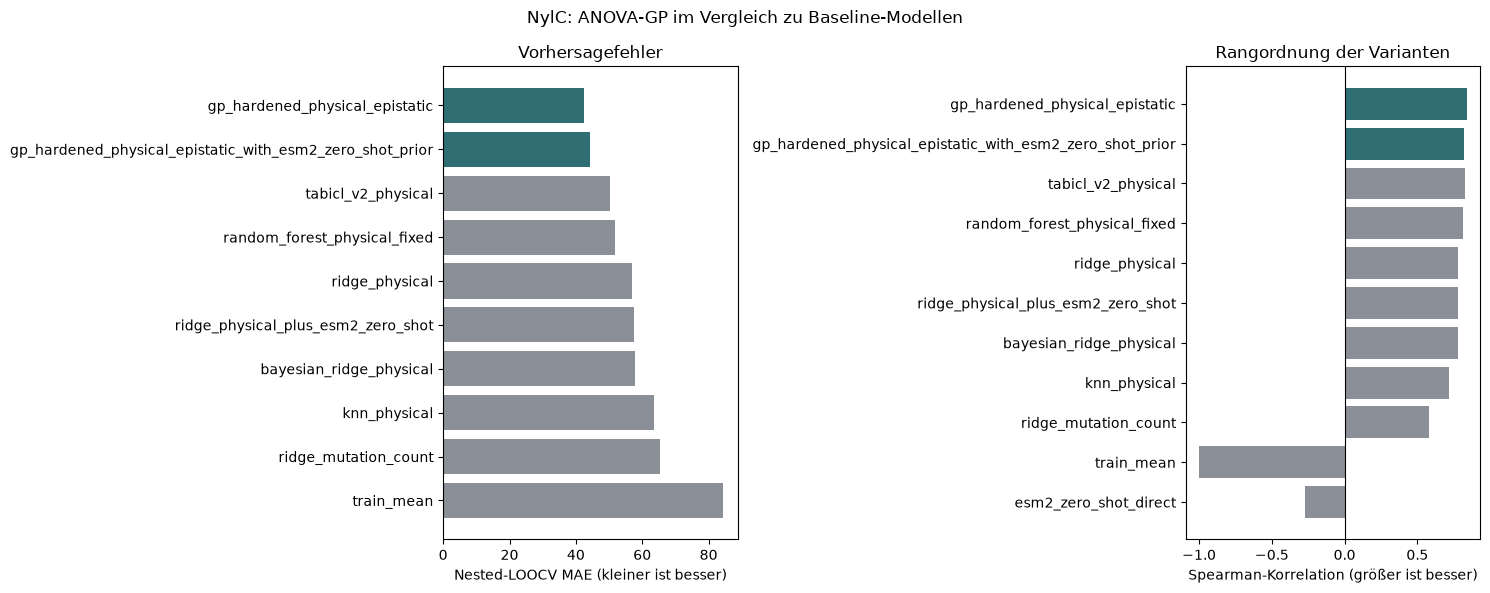

In [13]:
plot_df = metrics.sort_values('mae', ascending=True)
colors = ['#2f6f73' if name.startswith('gp_') else '#8a8f98' for name in plot_df['model']]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(plot_df['model'], plot_df['mae'], color=colors)
axes[0].invert_yaxis()
axes[0].set_xlabel('Nested-LOOCV MAE (kleiner ist besser)')
axes[0].set_title('Vorhersagefehler')
axes[1].barh(plot_df['model'], plot_df['spearman'], color=colors)
axes[1].invert_yaxis()
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Spearman-Korrelation (größer ist besser)')
axes[1].set_title('Rangordnung der Varianten')
fig.suptitle('NylC: ANOVA-GP im Vergleich zu Baseline-Modellen')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'model_comparison_mae_spearman.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Interpretation

Für die Bachelorarbeit sollte primär der verschachtelte LOOCV-MAE interpretiert werden. Spearman ist zusätzlich wichtig, wenn das Modell zur Priorisierung neuer Varianten eingesetzt wird. Unterschiede zwischen Modellen sollten wegen der kleinen Stichprobe anhand der paarweise gehaltenen absoluten Fehler und nicht nur anhand einzelner aggregierter Kennzahlen diskutiert werden.

TabICL V2 ist hier eine explorative Zero-Shot-Tabellenbaseline. Ein gutes Ergebnis wäre interessant, ersetzt wegen der deutlichen Abweichung vom Vortrainingsbereich jedoch nicht die domänenspezifische Validierung des ANOVA-GP.

In [14]:
best_model = metrics.iloc[0]['model']
gp_reference = 'gp_hardened_physical_epistatic'
paired = all_predictions.pivot(index='variant_id', columns='model', values='abs_error')
if gp_reference not in paired.columns:
    raise KeyError(f'GP-Referenz fehlt in der Auswertung: {gp_reference}')
gain_column = f'gain_{best_model}_vs_{gp_reference}'
paired = paired.assign(**{gain_column: paired[gp_reference] - paired[best_model]})
display(paired.sort_values(gain_column, ascending=False))

model,bayesian_ridge_physical,esm2_zero_shot_direct,gp_hardened_physical_epistatic,gp_hardened_physical_epistatic_with_esm2_zero_shot_prior,knn_physical,random_forest_physical_fixed,ridge_mutation_count,ridge_physical,ridge_physical_plus_esm2_zero_shot,tabicl_v2_physical,train_mean,gain_gp_hardened_physical_epistatic_vs_gp_hardened_physical_epistatic
variant_id,,,,,,,,,,,,
D304E,34.943422,NaN,43.917354,44.460178,30.320866,37.889842,6.412948,31.764496,32.239974,49.050674,70.642157,0.0
D304L,40.850409,NaN,75.608768,77.324716,62.246033,49.724359,42.081280,42.127183,47.606147,82.191071,105.384804,0.0
D304M,68.018672,NaN,47.620208,47.855746,96.000000,84.273788,59.375310,65.432590,63.119906,97.525146,6.561275,0.0
D304Q,15.842955,NaN,7.361052,14.048605,3.694680,15.531979,21.472910,12.966296,9.917486,11.842010,85.311275,0.0
D304R,29.580065,NaN,54.253049,37.993359,30.164997,35.002438,57.405453,32.215636,36.697579,19.995422,120.311275,0.0
D304V,42.807092,NaN,103.328027,49.136738,25.088224,16.224093,48.422317,44.004866,45.786221,1.334412,111.561275,0.0
D304W,64.416979,NaN,36.208741,34.252194,57.728952,24.775018,50.007576,65.824604,63.699245,10.035873,113.105392,0.0
D99G,17.733615,NaN,13.793029,8.906632,13.065401,13.304446,35.211824,13.472604,11.955073,21.393616,98.693627,0.0
D99G_F134W_D304M,18.056131,NaN,7.978189,7.272238,54.587873,63.978546,27.845652,15.326712,17.857704,11.076111,26.894608,0.0
